#### 1. What is IQR?

IQR tells us how spread out the middle 50% of the data is.

The formula is:

                IQR=Q3−Q1

                
Where:

- Q1 = 25th percentile
- Q2 = 50th percentile (median)
- Q3 = 75th percentile



***We commonly use IQR to detect outliers.***

*Outlier rule:*
- Lower Limit = Q1 - 1.5 × IQR
- Upper Limit = Q3 + 1.5 × IQR

### Load the tips dataset

In [1]:
import seaborn as sns

tips = sns.load_dataset("tips")

print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


### 2. Understand Q1 and Q3

In [3]:
# start with target veriable
Q1 = tips["total_bill"].quantile(0.25)
Q3 = tips["total_bill"].quantile(0.75)

print("Q1:", Q1)
print("Q3:", Q3)

Q1: 13.3475
Q3: 24.127499999999998


#### What does this mean?

Approximately:

- 25% of bills are less than or equal to $13.35


- 75% of bills are less than or equal to $24.13

The difference between these two values gives us the IQR.

### 3. Calculate IQR

In [4]:
IQR = Q3 - Q1

print("IQR:", IQR) 

#This means the middle(median) 50% of the total_bill values span about $10.77

IQR: 10.779999999999998


In [12]:
print(tips["total_bill"].describe())

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64


In [5]:
import matplotlib.pyplot as plt


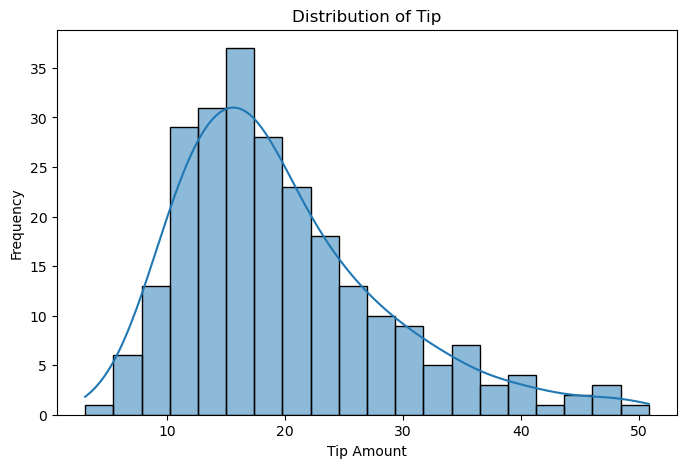

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    tips["total_bill"],
    bins=20,
    kde=True
)

plt.title("Distribution of Tip")
plt.xlabel("Tip Amount")
plt.ylabel("Frequency")

plt.show()

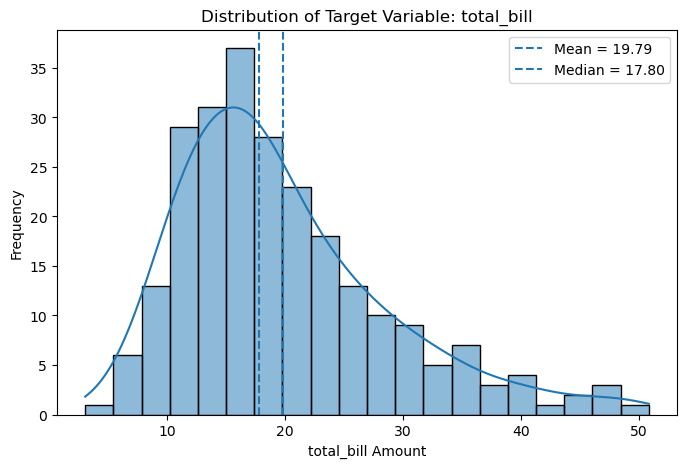

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    tips["total_bill"],
    bins=20,
    kde=True
)

# Mean
plt.axvline(
    tips["total_bill"].mean(),
    linestyle="--",
    label=f"Mean = {tips['total_bill'].mean():.2f}"
)

# Median
plt.axvline(
    tips["total_bill"].median(),
    linestyle="--",
    label=f"Median = {tips['total_bill'].median():.2f}"
)

plt.title("Distribution of Target Variable: total_bill")
plt.xlabel("total_bill Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()

## 4. Calculate the lower limit

Lower=Q1−1.5(IQR)

In [16]:
lower_limit = Q1 - 1.5 * IQR

print("Lower Limit:", lower_limit)

Lower Limit: -2.8224999999999945


## 5. Calculate the upper limit

Upper=Q3+1.5(IQR)

In [17]:
upper_limit = Q3 + 1.5 * IQR

print("Upper Limit:", upper_limit)

Upper Limit: 40.29749999999999


## 6. Find the outliers

In [18]:
outliers = tips[
    (tips["total_bill"] < lower_limit) |
    (tips["total_bill"] > upper_limit)
]

print(outliers)

     total_bill    tip     sex smoker   day    time  size
59        48.27   6.73    Male     No   Sat  Dinner     4
102       44.30   2.50  Female    Yes   Sat  Dinner     3
142       41.19   5.00    Male     No  Thur   Lunch     5
156       48.17   5.00    Male     No   Sun  Dinner     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
182       45.35   3.50    Male    Yes   Sun  Dinner     3
184       40.55   3.00    Male    Yes   Sun  Dinner     2
197       43.11   5.00  Female    Yes  Thur   Lunch     4
212       48.33   9.00    Male     No   Sat  Dinner     4


In [19]:
tips["total_bill"] > 40.2975

0      False
1      False
2      False
3      False
4      False
       ...  
239    False
240    False
241    False
242    False
243    False
Name: total_bill, Length: 244, dtype: bool

In [20]:
outliers = tips[tips["total_bill"] > upper_limit]

print(outliers)

     total_bill    tip     sex smoker   day    time  size
59        48.27   6.73    Male     No   Sat  Dinner     4
102       44.30   2.50  Female    Yes   Sat  Dinner     3
142       41.19   5.00    Male     No  Thur   Lunch     5
156       48.17   5.00    Male     No   Sun  Dinner     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
182       45.35   3.50    Male    Yes   Sun  Dinner     3
184       40.55   3.00    Male    Yes   Sun  Dinner     2
197       43.11   5.00  Female    Yes  Thur   Lunch     4
212       48.33   9.00    Male     No   Sat  Dinner     4


## 7. Count the outliers

In [21]:
print("Number of outliers:", len(outliers))

Number of outliers: 9


In [23]:
## 8. Let's visualize the outliers

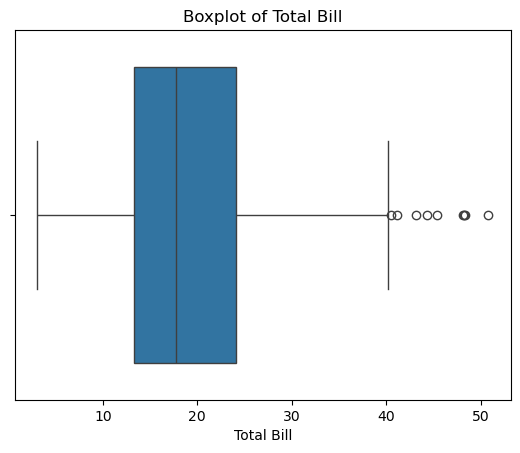

In [22]:
import seaborn as sns

sns.boxplot(x=tips["total_bill"])

plt.title("Boxplot of Total Bill")
plt.xlabel("Total Bill")

plt.show()

## code reuseability 

In [24]:
def find_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_limit) |
        (data[column] > upper_limit)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Limit:", lower_limit)
    print("Upper Limit:", upper_limit)
    print("Number of Outliers:", len(outliers))

    return outliers